In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Walmart_cleaned.csv")

In [4]:
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,74.69,7,05-01-2019,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,15.28,5,08-03-2019,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7,03-03-2019,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,58.22,8,27-01-2019,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,86.31,7,08-02-2019,10:37:00,Ewallet,5.3,0.48


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10000 non-null  int64  
 1   Branch          10000 non-null  object 
 2   City            10000 non-null  object 
 3   category        10000 non-null  object 
 4   unit_price      10000 non-null  object 
 5   quantity        10000 non-null  object 
 6   date            10000 non-null  object 
 7   time            10000 non-null  object 
 8   payment_method  10000 non-null  object 
 9   rating          10000 non-null  float64
 10  profit_margin   10000 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB


In [6]:
df.describe()

,invoice_id,rating,profit_margin
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,5.830170,0.393813
std,2886.89568,1.764097,0.090656
min,1.00000,3.000000,0.180000
25%,2500.75000,4.000000,0.330000
50%,5000.50000,6.000000,0.330000
75%,7500.25000,7.000000,0.480000
max,10000.00000,10.000000,0.570000


In [7]:
df.isnull().sum()

,0
invoice_id,0
Branch,0
City,0
category,0
unit_price,0
quantity,0
date,0
time,0
payment_method,0
rating,0


In [12]:
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['total_sales'] = df['unit_price'] * df['quantity']

In [14]:
city_sales = df.groupby("City")["total_sales"].sum().sort_values(ascending=False)

print(city_sales)

City
Weslaco         46351.79
Waxahachie      40703.33
Plano           25688.34
San Antonio     24950.56
Port Arthur     24524.37
                  ...   
Longview         6769.33
Pearland         6572.91
Irving           6237.11
Lewisville       5568.84
Lake Jackson     5038.90
Name: total_sales, Length: 98, dtype: float64


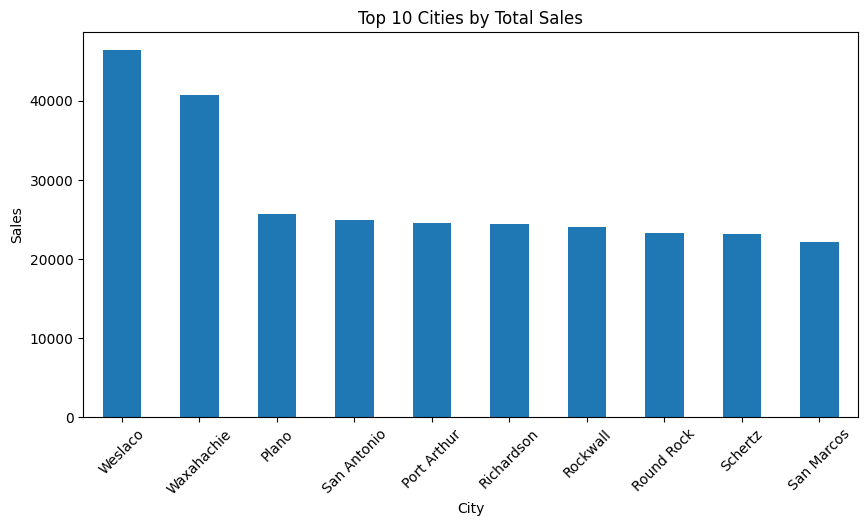

In [17]:
top_cities = df.groupby("City")["total_sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Total Sales")
plt.xlabel("City")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

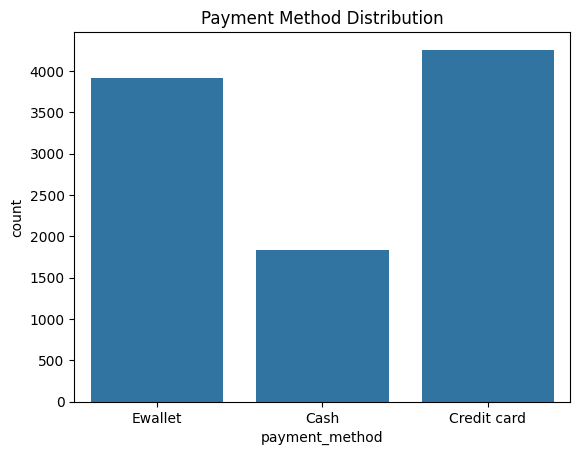

In [18]:
sns.countplot(x="payment_method", data=df)

plt.title("Payment Method Distribution")

plt.show()

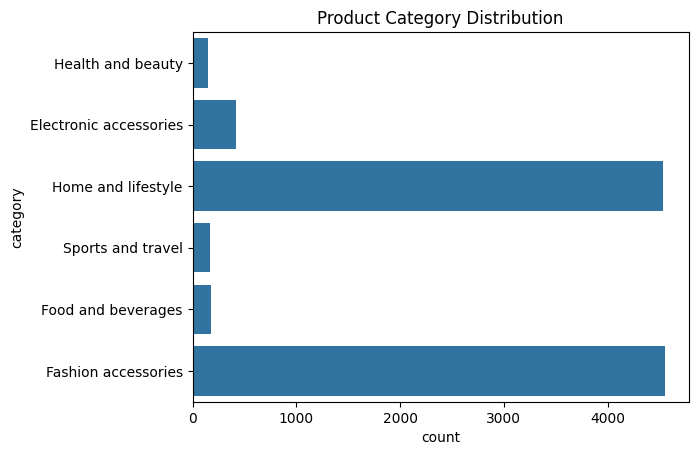

In [19]:
sns.countplot(y="category", data=df)

plt.title("Product Category Distribution")

plt.show()

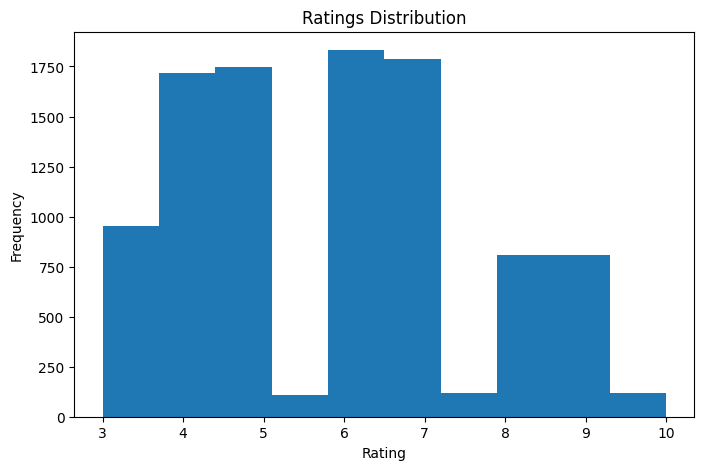

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=10)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

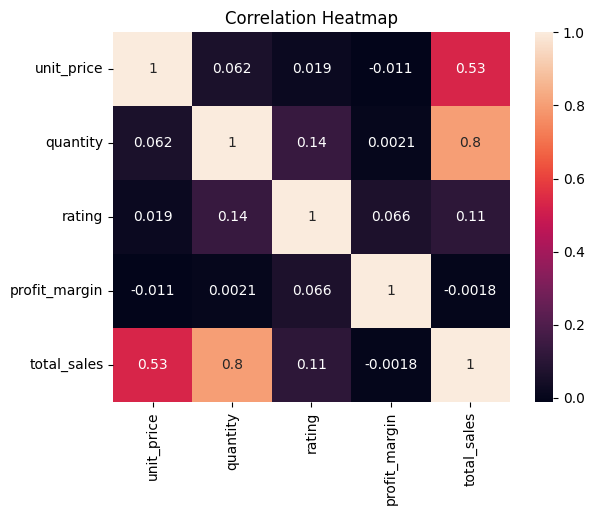

In [21]:
numeric_df = df[["unit_price", "quantity", "rating", "profit_margin", "total_sales"]]

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()